# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  Respuesta: Existen los siguientes valores faltantes:
  1. En el dataset "users", la columna "city" tiene un 11.725% de datos faltantes. Una cantidad significativa que podría crear un sesgo en el análisis. Lo recomendable sería investigar si corresponden todas a una misma ciudad que no se imputó correctamente o corresponde a un MCAR (lo cual no afectaría el resultado del análisis).
  2. En el dataset "users", la columna "churn_date" tiene un 88.35% de datos faltantes. Se recomienda no trabajar con esta columna ya que no existe suficiente información para realizar un análisis adecuado.
  3. En el dataset "usage", la columna "date" tiene un 0.125% de datos faltantes.
  4. En el dataset "usage", es importante mencionar que los datos faltantes en las columnas "duration" & "length" es normal y depende si en la columna "type" se define "call" o "text"; esto implicaría que la suma de faltantes debería ser igual al numero de entradas; sin embargo, esto no es así, por lo que en lugar de datos faltantes, hay datos "sobrantes".
- Indica qué harías: ¿imputar, eliminar, ignorar?
  Respuesta: A falta de avanzar y profundizar en el análisis, inicialmente se recomienda para cada caso correspondiente a la respuesta anterior:
  1. Investigar más para decidir si imputar o ignorar
  2. Eliminar columna
  3. Impurtar
  4. Eliminar datos sobrantes

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
columnas_numericas = ['user_id', 'age']
users[columnas_numericas].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene registrados usuarios entre el valor 10000 al 13999 imputados correctamente de uno en uno.
- La columna `age` tiene un valor por defecto de -999 (probablemente para valores nulos), valor ilógico para un valor de edad. Lo adecuado sería reemplazar estos valores por nulos para que no se afecten métricas como el promedio y la desviación estándar.

In [13]:
# explorar columnas numéricas de usage
columnas_numericas = ['id', 'user_id','duration','length']
usage[columnas_numericas].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` se comportan adecuadamente como era esperado.
- Las columnas 'duration' y 'length' parecen contener outliers con valores máximos muy altos. Probablemente correspondan a los datos sobrantes que se mencionó previamente.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` tiene varios datos faltantes.
- La columna `plan` está correctamente imputada.

In [15]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` tiene dos opciones únicas como se mencionaba previamente; y "text" es el valor más común.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  Respuesta: Se identificaron los siguiente valores inválidos o sentinels
  1. La columna `age`, del dataset 'users' tiene un valor por defecto de -999 (probablemente para valores nulos), valor ilógico para un valor de edad.
  2. Las columnas 'duration' y 'length' parecen contener outliers con valores máximos muy altos.
- ¿Qué acción tomarías?
  Respuesta: Se tomarían las acciones correspondientes según el caso.
  1. Lo adecuado sería reemplazar estos valores por nulos para que no se afecten métricas como el promedio y la desviación estándar.
  2. Probablemente correspondan a los datos sobrantes que se mencionó previamente y se deberían eliminar esos datos sobrantes.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'],errors="coerce",utc=True)

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'],errors="coerce",utc=True)

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` se puede observar que hay 40 datos correspondientes al año 2026, lo cuál no es correcto dado que se menciona que los datos registrados son hasta el año 2024.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date` todos los datos corresponden a 2024.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Respuesta: Sí, hay datos de registros del 2026.
- ¿Qué harías con ellas?
  Respuesta: Eliminarlos ya que son muy pocos datos en proporción.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace("?",pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
mask = users['reg_date'].dt.year == 2026
users.loc[mask,"reg_date"]=pd.NA

# Verificar cambios
users['reg_date'].describe()

count                                    3960
unique                                   3960
top       2023-12-20 18:33:45.506376600+00:00
freq                                        1
first               2022-01-01 00:00:00+00:00
last                2024-12-31 00:00:00+00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64

In [25]:
# Verificación MAR en usage (Missing At Random) para ambas columnas
usage.groupby('type')[['duration', 'length']].apply(lambda x: x.isna().sum())

,duration,length
type,,
call,0,17896
text,22076,0


Los valores nulos en `duration` y `length` dependen de la columna 'type', por lo que es aceptable que haya valores nulos en ambas columnas.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Renombrar columnas
usage_agg=usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users,usage_agg,on=["user_id"],how="inner")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [29]:
# Resumen estadístico de las columnas numéricas
columnas_num = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]
user_profile[columnas_num].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


In [30]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True)

Basico     0.648662
Premium    0.351338
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

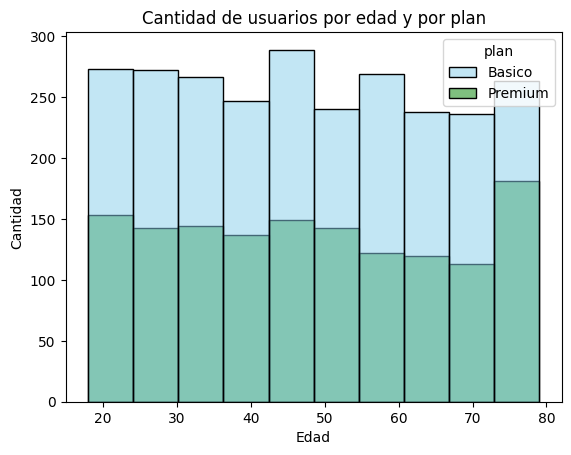

In [41]:
# Histograma para visualizar la edad (age)


sn.histplot(data=user_profile, x="age", bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.title("Cantidad de usuarios por edad y por plan")
plt.show()



💡Insights: 
Existe una distribución equiparable entre los distintos grupos de edad sin que haya un grupo de edad por encima del resto. Sin embargo, se puede obser var que el grupo de mayor edad tiene una mayor proporción de usuarios premium sobre usuarios del plan básico.

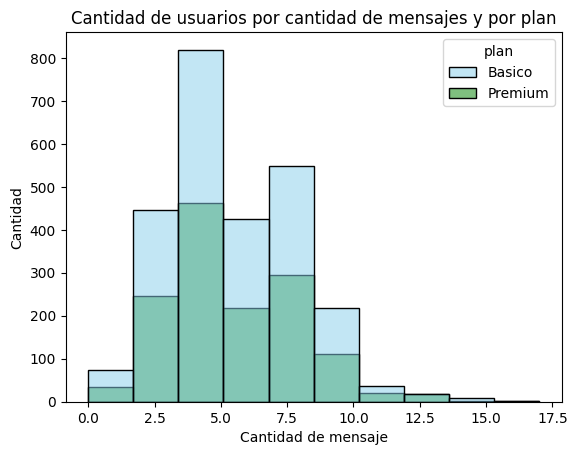

In [42]:
# Histograma para visualizar la cant_mensajes
sn.histplot(data=user_profile, x="cant_mensajes", bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel("Cantidad de mensaje")
plt.ylabel("Cantidad")
plt.title("Cantidad de usuarios por cantidad de mensajes y por plan")
plt.show()

💡Insights: 
- Existe una gran proporción de usuarios que mandan en promedio casi 5 mensajes de texto.

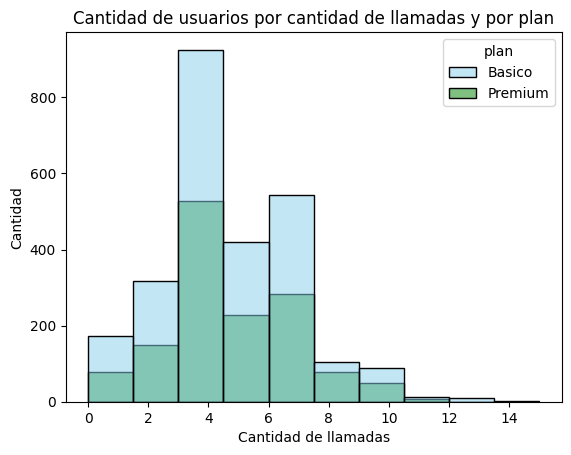

In [43]:
# Histograma para visualizar la cant_llamadas
sn.histplot(data=user_profile, x="cant_llamadas", bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad")
plt.title("Cantidad de usuarios por cantidad de llamadas y por plan")
plt.show()

💡Insights: 
- Existe una mayor cantidad de usuarios que hacen aproximadamente 4 llamadas.

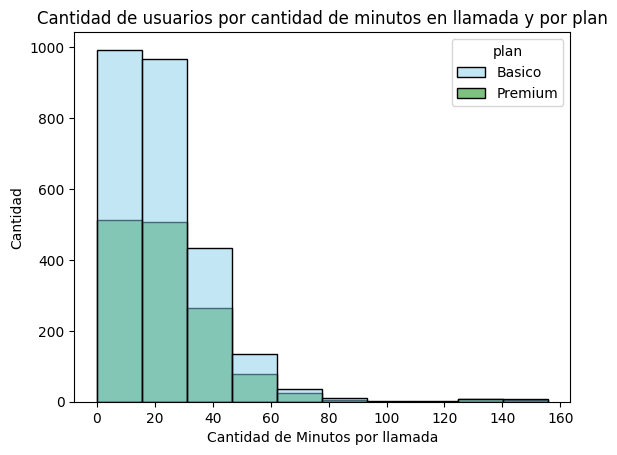

In [44]:
# Histograma para visualizar la cant_minutos_llamada
sn.histplot(data=user_profile, x="cant_minutos_llamada", bins=10, hue='plan', palette=['skyblue','green'])
plt.xlabel("Cantidad de Minutos por llamada")
plt.ylabel("Cantidad")
plt.title("Cantidad de usuarios por cantidad de minutos en llamada y por plan")
plt.show()

💡Insights: 
- La gran mayoría de usuarios hace llamadas por menos de 40 minutos. Sin embargo, del gráfico se puede observar que a mayor cantidad de minutos la proporción de usuarios premium aumenta. Esto quiere decir que los usuarios con largas llamadas suelen ser usuarios del plan premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

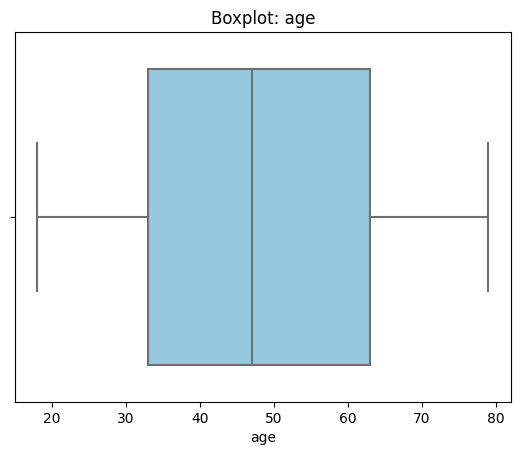

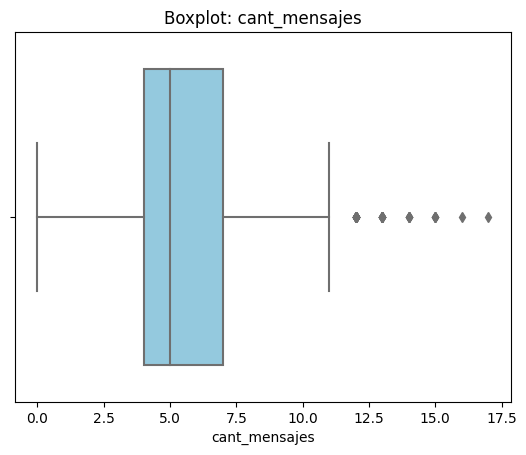

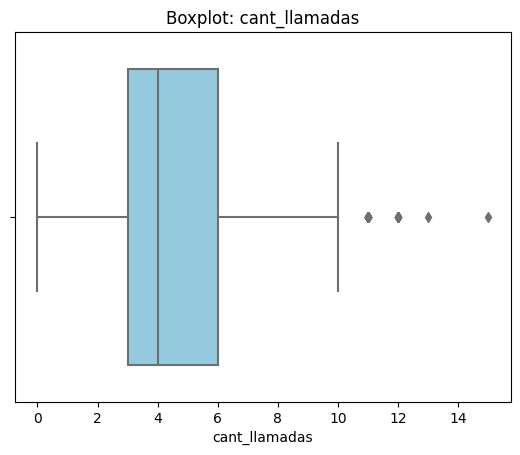

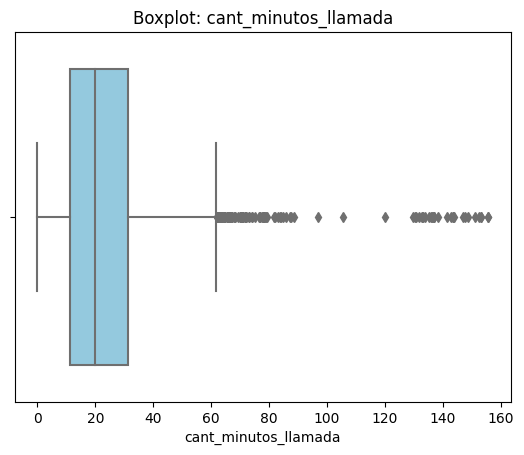

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas :
    sn.boxplot(x=user_profile[col],color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers, como era de esperarse después de haber hecho la limpieza del dataset.
- cant_mensajes: presenta algunos outliers.
- cant_llamadas: presenta pocos outliers. 
- cant_minutos_llamada: presenta muchos outliers. Esto es de esperarse ya que los usuarios premium pueden tener ventaja de hacer llamadas más largas.

In [46]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites :
    Q1=user_profile[col].quantile(0.25)
    Q3=user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"De la columna '{col}' | IQR: {IQR:.2f} | Límite inferior: {lower:.2f} | Límite superior: {upper:.2f}")

De la columna 'cant_mensajes' | IQR: 3.00 | Límite inferior: -0.50 | Límite superior: 11.50
De la columna 'cant_llamadas' | IQR: 3.00 | Límite inferior: -1.50 | Límite superior: 10.50
De la columna 'cant_minutos_llamada' | IQR: 20.30 | Límite inferior: -19.32 | Límite superior: 61.86


In [47]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener outliers, porque son datos reales
- cant_llamadas: mantener outliers, porque son datos reales
- cant_minutos_llamada: mantener outliers, porque son datos reales

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [49]:
# Crear columna grupo_uso
def classify(row):
    mens = row['cant_mensajes']
    llam = row['cant_llamadas']

    # --- 1. Segmentación de Bajo uso ---
    if mens < 5:
        if llam < 5:
            return "Bajo uso"
        else: # Se asignará "Alto uso" al caso de muchas llamadas pero pocos mensajes
            return "Alto uso"
            
    # --- 2. Segmentación de Uso medio ---
    elif mens < 10:
        if llam < 10:
            return "Uso medio"
        else: # Se asignará "Alto uso" al caso de muchas llamadas pero cantidad media de mensajes
            return "Alto uso"
    
    # --- 3. Segmentación de Alto uso ---
    else :
        return "Alto uso"    

# aplicar función y verificar cambios
user_profile["grupo_uso"] = user_profile.apply(classify,axis=1)

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [51]:
# Crear columna grupo_edad
def classify_age(row):
    age = row['age']

    # --- 1. Segmentación de Jóvenes ---
    if age < 30:
        return "Joven"
            
    # --- 2. Segmentación de Adultos ---
    elif age < 60:
        return "Adulto"
    
    # --- 3. Segmentación de Adultos Mayores ---
    else :
        return "Adulto Mayor"    

# aplicar función y verificar cambios
user_profile["grupo_edad"] = user_profile.apply(classify_age,axis=1)

In [52]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

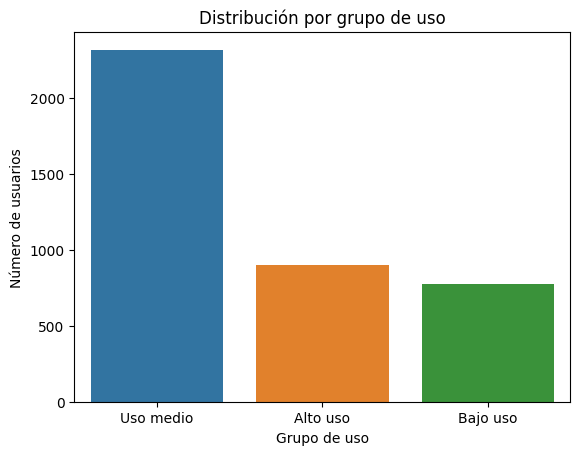

In [54]:
# Visualización de los segmentos por uso
sn.countplot(x='grupo_uso', data=user_profile)
plt.title('Distribución por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')
plt.show()

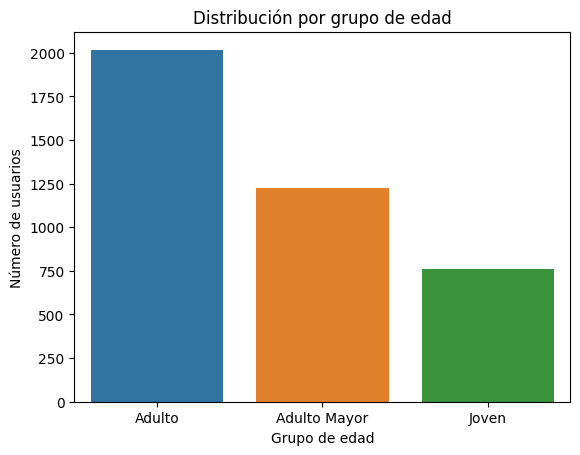

In [55]:
# Visualización de los segmentos por edad
sn.countplot(x='grupo_edad', data=user_profile)
plt.title('Distribución por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Número de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
Durante la exploración inicial se identificaron diversos problemas de calidad de datos que podían afectar el análisis:

**Edad:** Se detectó un valor centinela de -999, utilizado para representar datos faltantes o incorrectos. Este valor fue reemplazado por valores nulos y posteriormente imputado utilizando la mediana de edad para mantener la consistencia del análisis.
**Ciudad:** Se encontraron 469 registros sin ciudad, equivalentes al 11.7% de los clientes (469 de 4,000 registros). Estos valores se conservaron como datos faltantes, ya que no era posible inferir la ciudad de manera confiable.
**Fecha de registro:** Se identificaron 40 fechas inválidas, aproximadamente el 1.0% de los registros, las cuales fueron convertidas a valores nulos para evitar errores en el procesamiento.
**Variables de uso:** Las columnas de duración de llamadas y longitud de mensajes presentaban valores nulos porque cada registro corresponde únicamente a un tipo de actividad (llamada o mensaje). Estos valores forman parte de la estructura del dataset y no representan errores de captura.

Después del proceso de limpieza, los datos quedaron consistentes y listos para el análisis estadístico.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
Se construyeron dos tipos de segmentación:

Por edad, clasificando a los clientes en jóvenes, adultos y adultos mayores.
Por nivel de uso, agrupando a los usuarios en bajo uso, uso medio y alto uso según el volumen de llamadas y mensajes registrados.

El análisis mostró que la mayor parte de los clientes se concentra en los segmentos de uso medio, mientras que los usuarios de alto uso representan una proporción menor pero generan un consumo considerablemente superior al promedio.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
Es una pregunta dificil de responder porque no se ha evaluado el impacto económico que tiene cada segmento. Porque si bien el grupo de uso medio es muy alto comparado es probable que el grupo de alto uso implique mayores ingresos. Sin embargo, por otro lado, podría considerarse un grupo valioso para ConnectaTel el segmento de edad Adulto debido a su mayoritaria participación en su cartera de clientes con lo cual podría crear campañas de marketing enfocadas a este grupo.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
El análisis mediante histogramas y diagramas de caja permitió identificar usuarios con un volumen de llamadas, minutos consumidos o mensajes muy superior al comportamiento habitual.

Estos casos pueden representar clientes con necesidades de comunicación significativamente mayores al promedio, o bien, usuarios con perfiles empresariales o de alto consumo.

En lugar de eliminar estos registros, se conservaron para que puedan analizarse como un segmento específico de alto valor o como casos que requieren validación adicional.


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
Con base en los resultados obtenidos, se proponen las siguientes acciones:

Diseñar planes diferenciados para los clientes de alto consumo, incorporando mayores beneficios en llamadas y mensajes para incrementar la fidelización.
Implementar campañas de migración para usuarios de uso medio hacia planes superiores mediante promociones personalizadas.
Crear ofertas específicas para los diferentes grupos de edad, considerando que los hábitos de uso varían entre segmentos demográficos.
Implementar un monitoreo periódico de usuarios con comportamiento atípico para identificar oportunidades comerciales o detectar posibles anomalías de manera temprana.
Mantener procesos de validación y limpieza de datos antes de realizar análisis periódicos, garantizando que las decisiones comerciales se basen en información confiable.

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la exploración inicial se identificaron diversos problemas de calidad de datos que podían afectar el análisis:

**Edad:** Se detectó un valor centinela de -999, utilizado para representar datos faltantes o incorrectos. Este valor fue reemplazado por valores nulos y posteriormente imputado utilizando la mediana de edad para mantener la consistencia del análisis.
**Ciudad:** Se encontraron 469 registros sin ciudad, equivalentes al 11.7% de los clientes (469 de 4,000 registros). Estos valores se conservaron como datos faltantes, ya que no era posible inferir la ciudad de manera confiable.
**Fecha de registro:** Se identificaron 40 fechas inválidas, aproximadamente el 1.0% de los registros, las cuales fueron convertidas a valores nulos para evitar errores en el procesamiento.
**Variables de uso:** Las columnas de duración de llamadas y longitud de mensajes presentaban valores nulos porque cada registro corresponde únicamente a un tipo de actividad (llamada o mensaje). Estos valores forman parte de la estructura del dataset y no representan errores de captura.

Después del proceso de limpieza, los datos quedaron consistentes y listos para el análisis estadístico.


🔍 **Segmentos por Edad**

Se construyeron dos tipos de segmentación:

Por edad, clasificando a los clientes en jóvenes, adultos y adultos mayores.
Se detectó que el segmento principal de la cartera de clientes corresponde a adultos. Esta segmentación por edad  facilitan el diseño de ofertas más específicas para cada grupo.


📊 **Segmentos por Nivel de Uso**
Por nivel de uso, agrupando a los usuarios en bajo uso, uso medio y alto uso según el volumen de llamadas y mensajes registrados.

El análisis mostró que la mayor parte de los clientes se concentra en los segmentos de uso medio, mientras que los usuarios de alto uso representan una proporción menor pero podrían generar un consumo considerablemente superior al promedio lo que implique mayores ingresos provenientes de este segmento.


➡️ Esto sugiere que ...


💡 **Recomendaciones**
Con base en los resultados obtenidos, se proponen las siguientes acciones:

- Diseñar planes diferenciados para los clientes de alto consumo, incorporando mayores beneficios en llamadas y mensajes para incrementar la fidelización.
- Implementar campañas de migración para usuarios de uso medio hacia planes superiores mediante promociones dirigidas a segmentos.
- Implementar un monitoreo periódico de usuarios con comportamiento atípico para identificar oportunidades comerciales o detectar posibles anomalías de manera temprana.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`